# Exploratory Data Analysis

This notebook explores the prepared financial time-series dataset used to predict future 5-day Microsoft (MSFT) returns.

The main goals of this notebook are:

- inspect the dataset structure
- understand the feature distribution
- check missing values
- study correlations between variables
- visualize the target series over time

In [16]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [17]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_data import load_dataset, split_features_target

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [19]:
df = load_dataset()
X, y = split_features_target(df)

print("Dataset shape:", df.shape)
print("Number of features:", X.shape[1])
print("Target name:", y.name)

Dataset shape: (184, 22)
Number of features: 21
Target name: MSFT_pred


In [20]:
df.head()

,MSFT_pred,GOOGL,IBM,DEXJPUS,DEXUSUK,SP500,DJIA,VIXCLS,MSFT_DT,MSFT_3DT,MSFT_6DT,MSFT_12DT,RSI,MACD,BB_Width,ATR,ROC,Gold_Return,Oil_Return,Treasury_Change,BTC_Return,Rolling_Beta
2016-04-29,0.0241,-0.0376,-0.0174,-0.0421,0.0162,-0.0126,-0.0129,0.1719,-0.0414,-0.0703,-0.0690,-0.0570,29.3384,-0.7500,15.4244,6.6479,-10.3864,0.0481,0.0489,-0.0600,-0.0076,1.2322
2016-05-06,-0.0005,0.0104,0.0188,-0.0022,-0.0128,-0.0040,-0.0019,-0.0645,0.0241,-0.0729,-0.0401,0.0256,36.9213,-1.0253,19.3216,6.5624,-2.6844,0.0029,-0.0278,-0.0400,0.0170,1.1264
2016-05-13,-0.0043,0.0136,0.0029,0.0230,-0.0049,-0.0051,-0.0116,0.0215,-0.0005,-0.0177,-0.0600,0.0102,43.8793,-0.7132,17.3356,6.6164,2.4264,-0.0164,0.0341,-0.0800,-0.0063,0.9639
2016-05-20,0.0352,-0.0021,-0.0032,0.0126,0.0100,0.0028,-0.0020,0.0106,-0.0043,0.0193,-0.0510,-0.0102,45.0521,-0.5008,5.3158,6.5292,1.1591,-0.0155,0.0328,0.1400,-0.0331,1.2050
2016-05-27,-0.0237,0.0330,0.0373,-0.0060,0.0090,0.0225,0.0210,-0.1472,0.0352,0.0304,-0.0424,0.0216,56.1462,-0.0906,6.6233,6.4944,3.1440,-0.0313,0.0326,0.0000,0.0748,1.3025


In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MSFT_pred,184.0000,0.0036,0.0320,-0.1592,-0.0104,0.0051,0.0243,0.0797
GOOGL,184.0000,0.0064,0.0277,-0.1033,-0.0078,0.0058,0.0244,0.0909
IBM,184.0000,0.0003,0.0302,-0.0858,-0.0108,0.0007,0.0158,0.0901
DEXJPUS,184.0000,-0.0000,0.0122,-0.0421,-0.0075,0.0012,0.0080,0.0364
DEXUSUK,184.0000,-0.0007,0.0150,-0.1055,-0.0101,0.0005,0.0097,0.0373
SP500,184.0000,0.0015,0.0192,-0.0893,-0.0043,0.0036,0.0120,0.0566
DJIA,184.0000,0.0016,0.0199,-0.0930,-0.0049,0.0038,0.0134,0.0546
VIXCLS,184.0000,0.0058,0.1748,-0.5591,-0.0896,-0.0009,0.0789,0.9099
MSFT_DT,184.0000,0.0033,0.0321,-0.1592,-0.0106,0.0050,0.0243,0.0797
MSFT_3DT,184.0000,0.0093,0.0475,-0.1366,-0.0170,0.0147,0.0390,0.1337


In [22]:
df.isnull().sum()


MSFT_pred          0
GOOGL              0
IBM                0
DEXJPUS            0
DEXUSUK            0
SP500              0
DJIA               0
VIXCLS             0
MSFT_DT            0
MSFT_3DT           0
MSFT_6DT           0
MSFT_12DT          0
RSI                0
MACD               0
BB_Width           0
ATR                0
ROC                0
Gold_Return        0
Oil_Return         0
Treasury_Change    0
BTC_Return         0
Rolling_Beta       0
dtype: int64

## Target Distribution
The target variable is the future 5-day MSFT return.  
Below, I check its distribution and how it behaves over time.

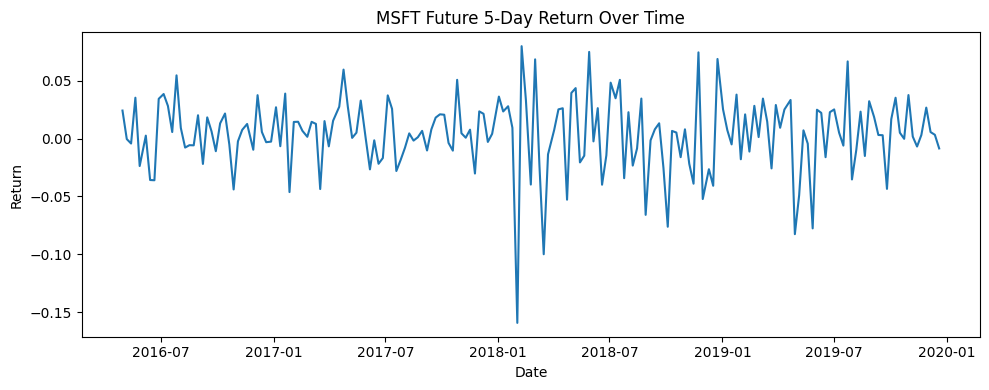

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(y.index, y.values)
plt.title("MSFT Future 5-Day Return Over Time")
plt.xlabel("Date")
plt.ylabel("Return")
plt.tight_layout()
plt.show()

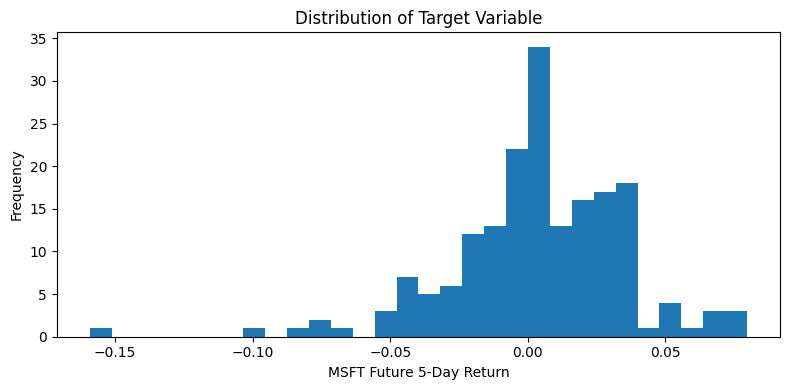

In [24]:
plt.figure(figsize=(8, 4))
plt.hist(y, bins=30)
plt.title("Distribution of Target Variable")
plt.xlabel("MSFT Future 5-Day Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Feature Distributions
I now look at the feature distributions to check scale differences, spread, and possible outliers.

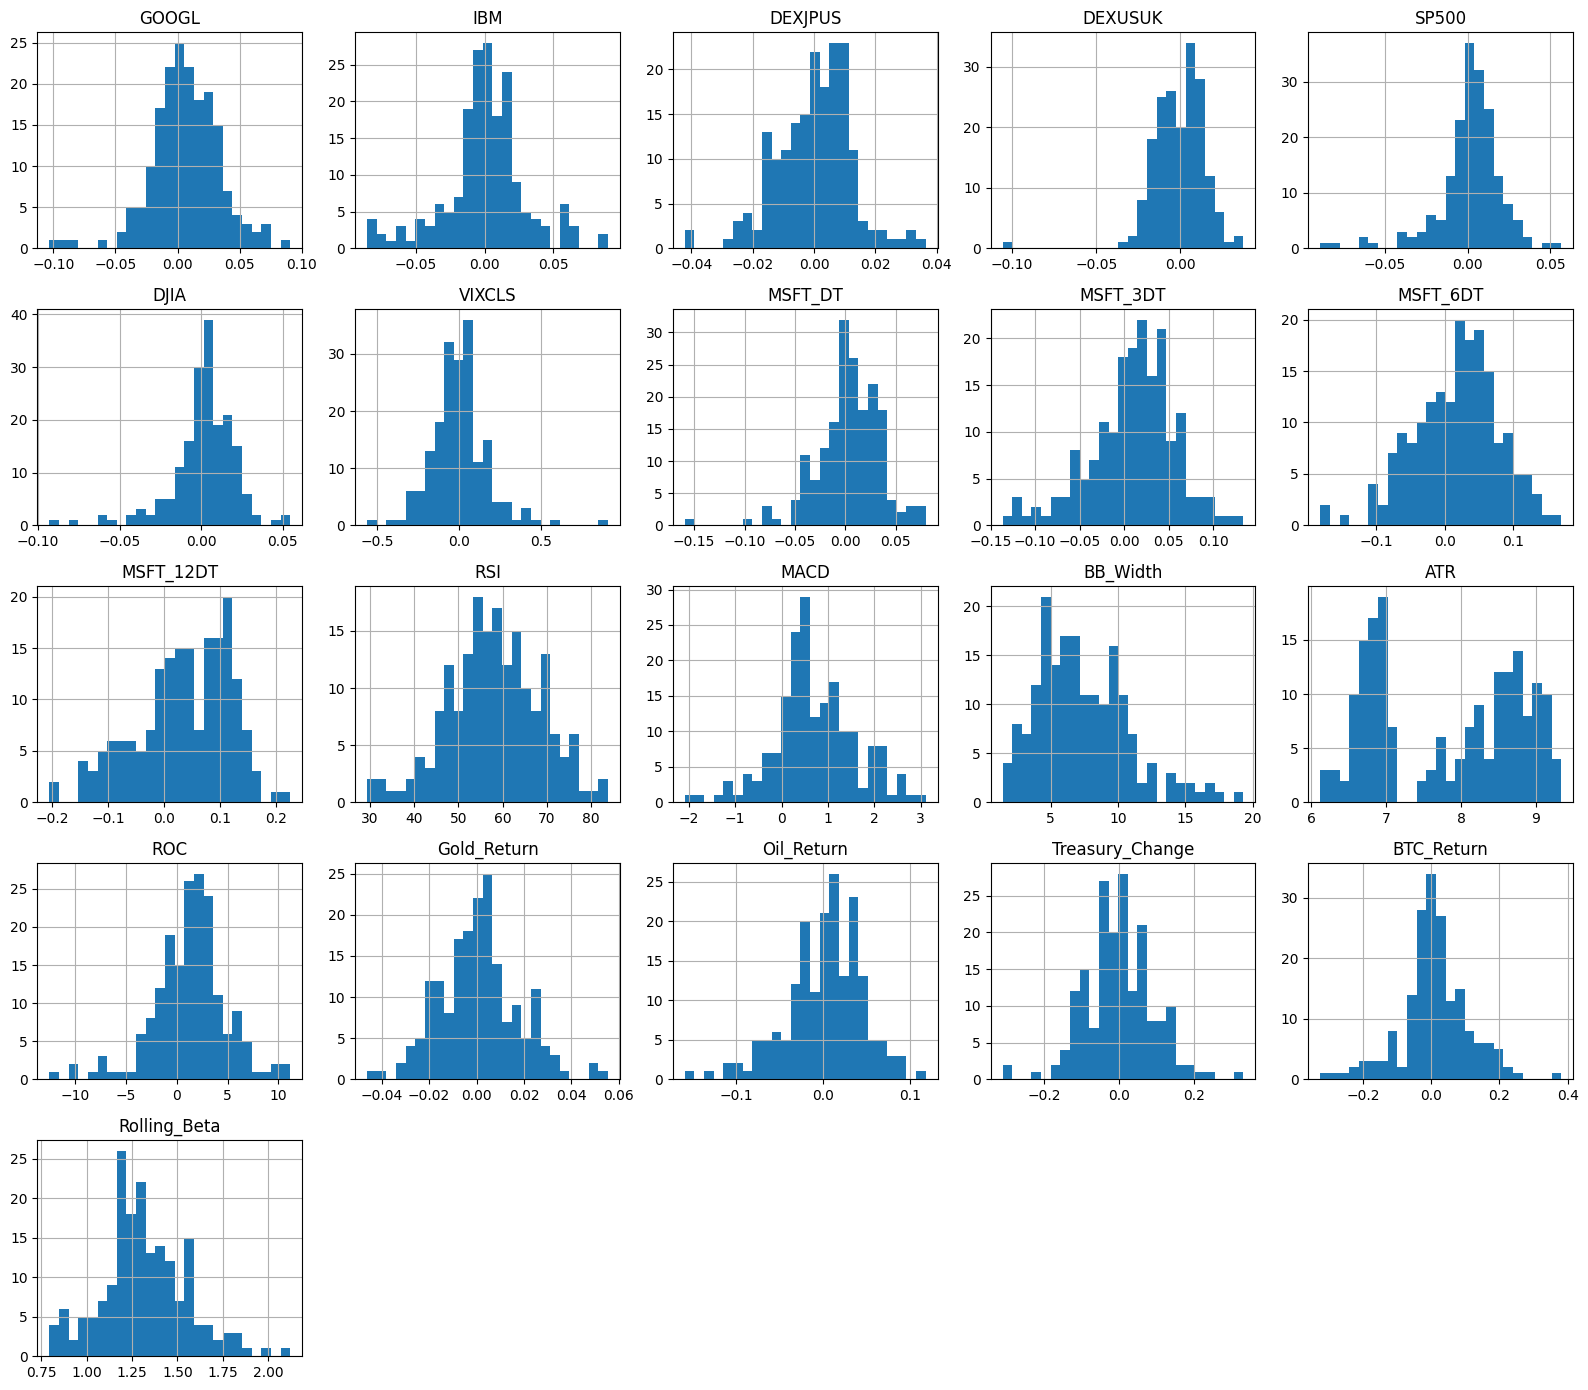

In [25]:
X.hist(bins=25, figsize=(16, 14))
plt.tight_layout()
plt.show()

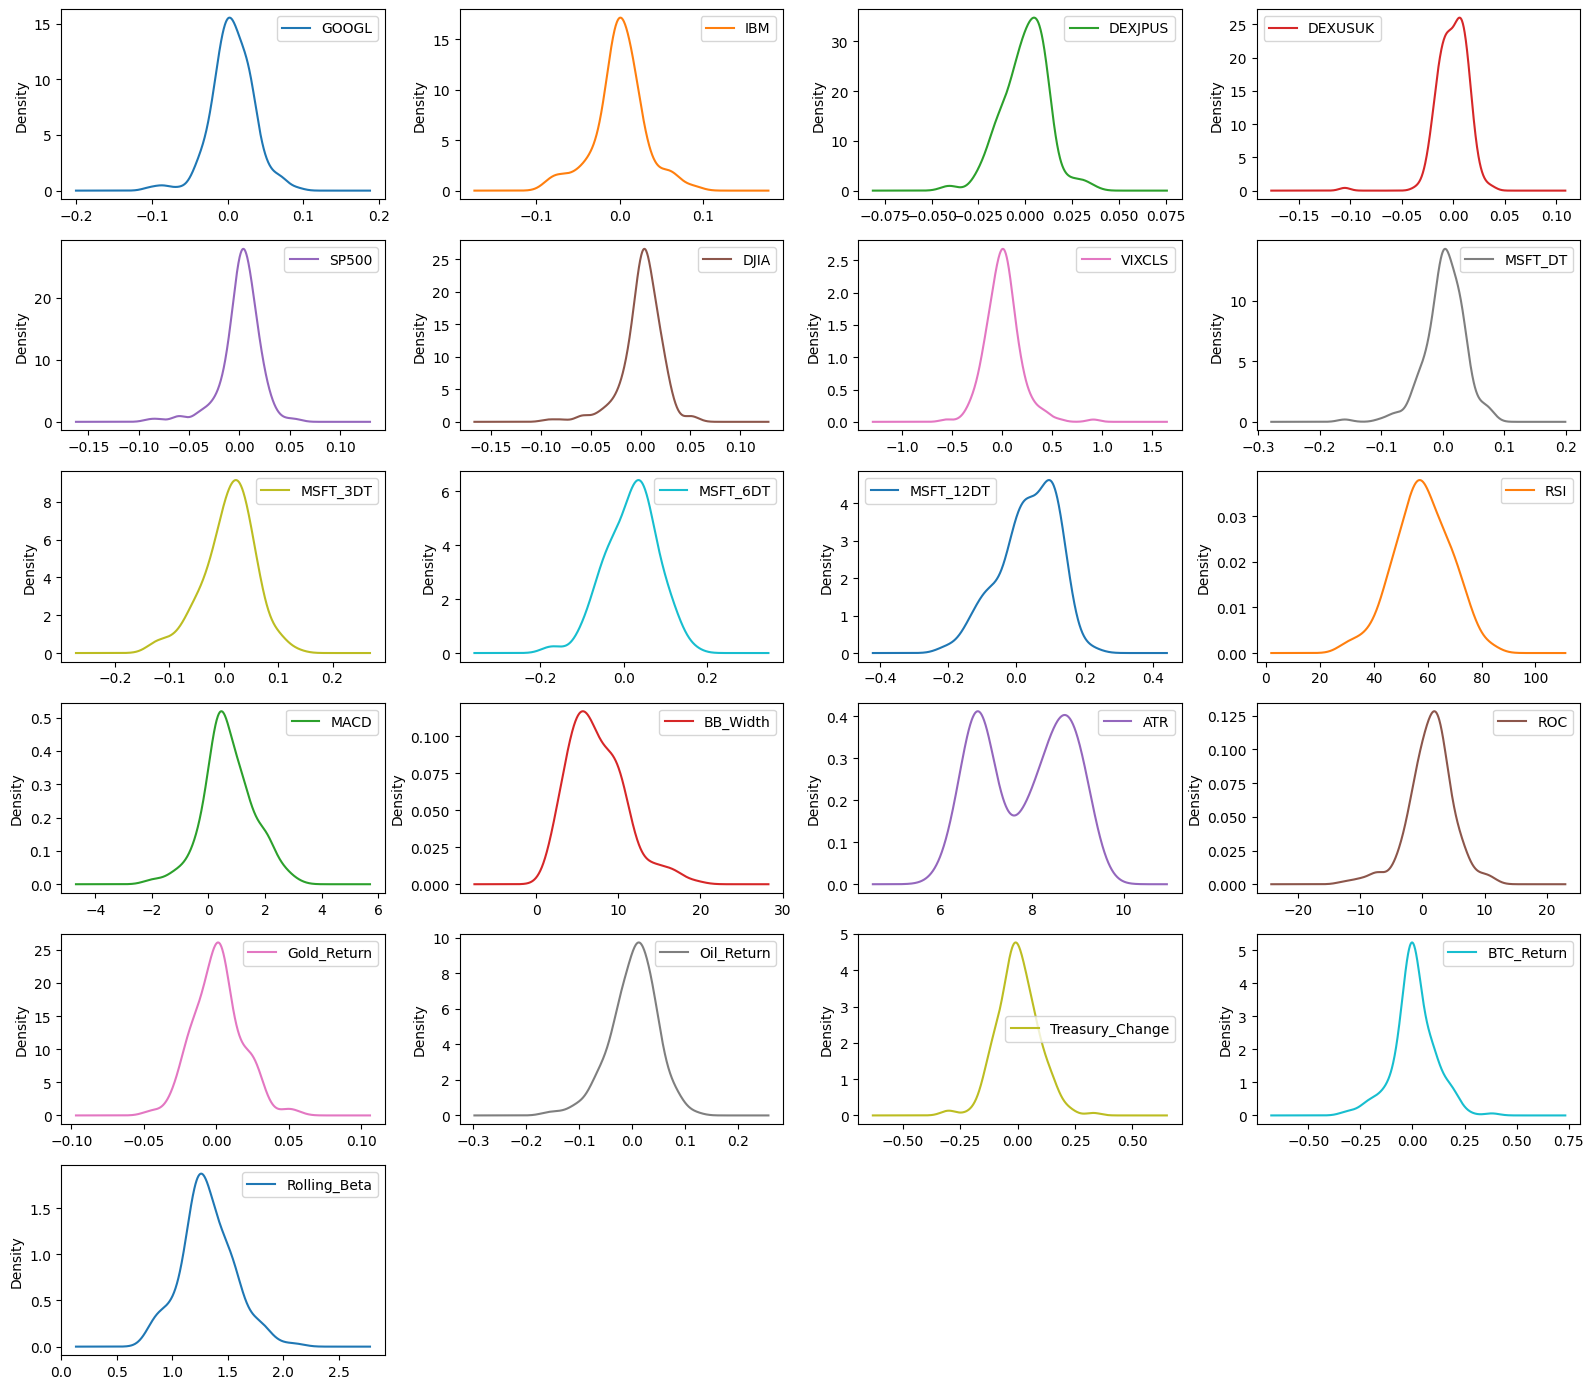

In [26]:
X.plot(kind="density", subplots=True, layout=(6, 4), figsize=(16, 14), sharex=False)
plt.tight_layout()
plt.show()

## Correlation Analysis
This helps check which features are more strongly related to the target and whether some features are highly correlated with each other.

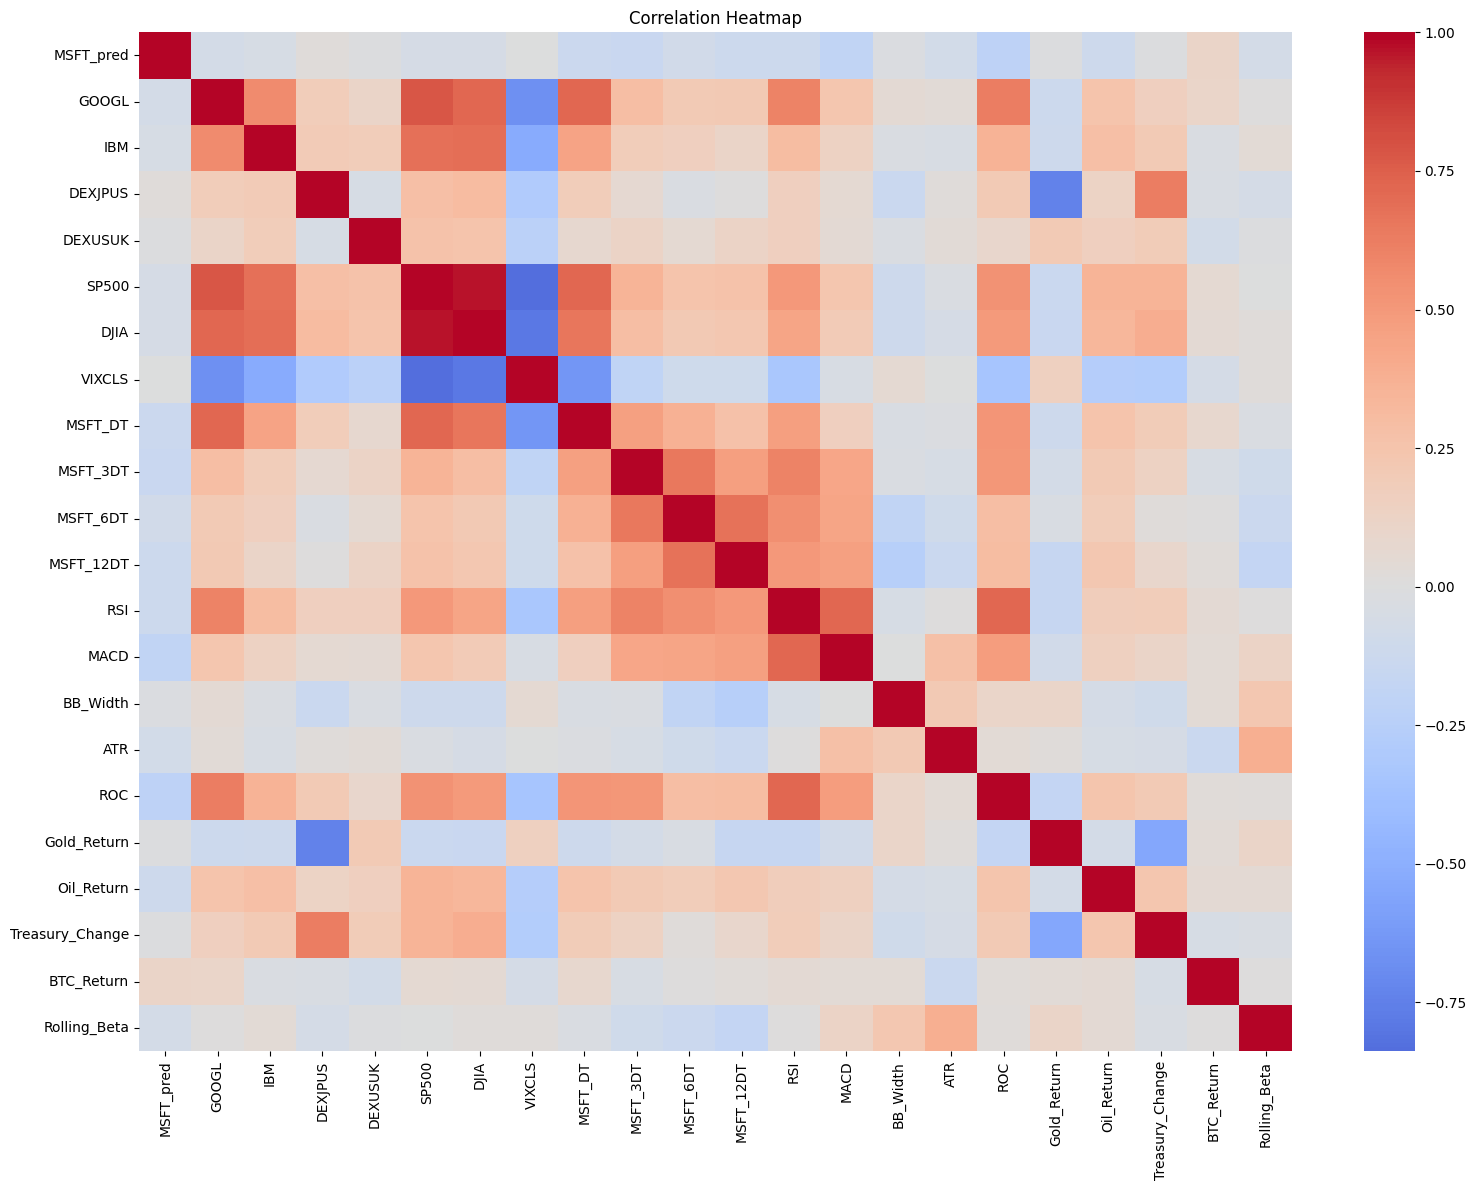

In [27]:
corr = df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [28]:
target_corr = corr["MSFT_pred"].sort_values(ascending=False)
target_corr

MSFT_pred          1.0000
BTC_Return         0.1116
DEXJPUS            0.0194
VIXCLS            -0.0018
DEXUSUK           -0.0052
Treasury_Change   -0.0063
Gold_Return       -0.0103
BB_Width          -0.0190
IBM               -0.0537
SP500             -0.0579
DJIA              -0.0586
Rolling_Beta      -0.0707
GOOGL             -0.0736
ATR               -0.0827
MSFT_6DT          -0.0907
Oil_Return        -0.1177
MSFT_12DT         -0.1250
RSI               -0.1265
MSFT_DT           -0.1314
MSFT_3DT          -0.1478
MACD              -0.1864
ROC               -0.2151
Name: MSFT_pred, dtype: float64

In [29]:
top_features = target_corr.drop("MSFT_pred").abs().sort_values(ascending=False).head(8).index.tolist()
top_features

['ROC',
 'MACD',
 'MSFT_3DT',
 'MSFT_DT',
 'RSI',
 'MSFT_12DT',
 'Oil_Return',
 'BTC_Return']

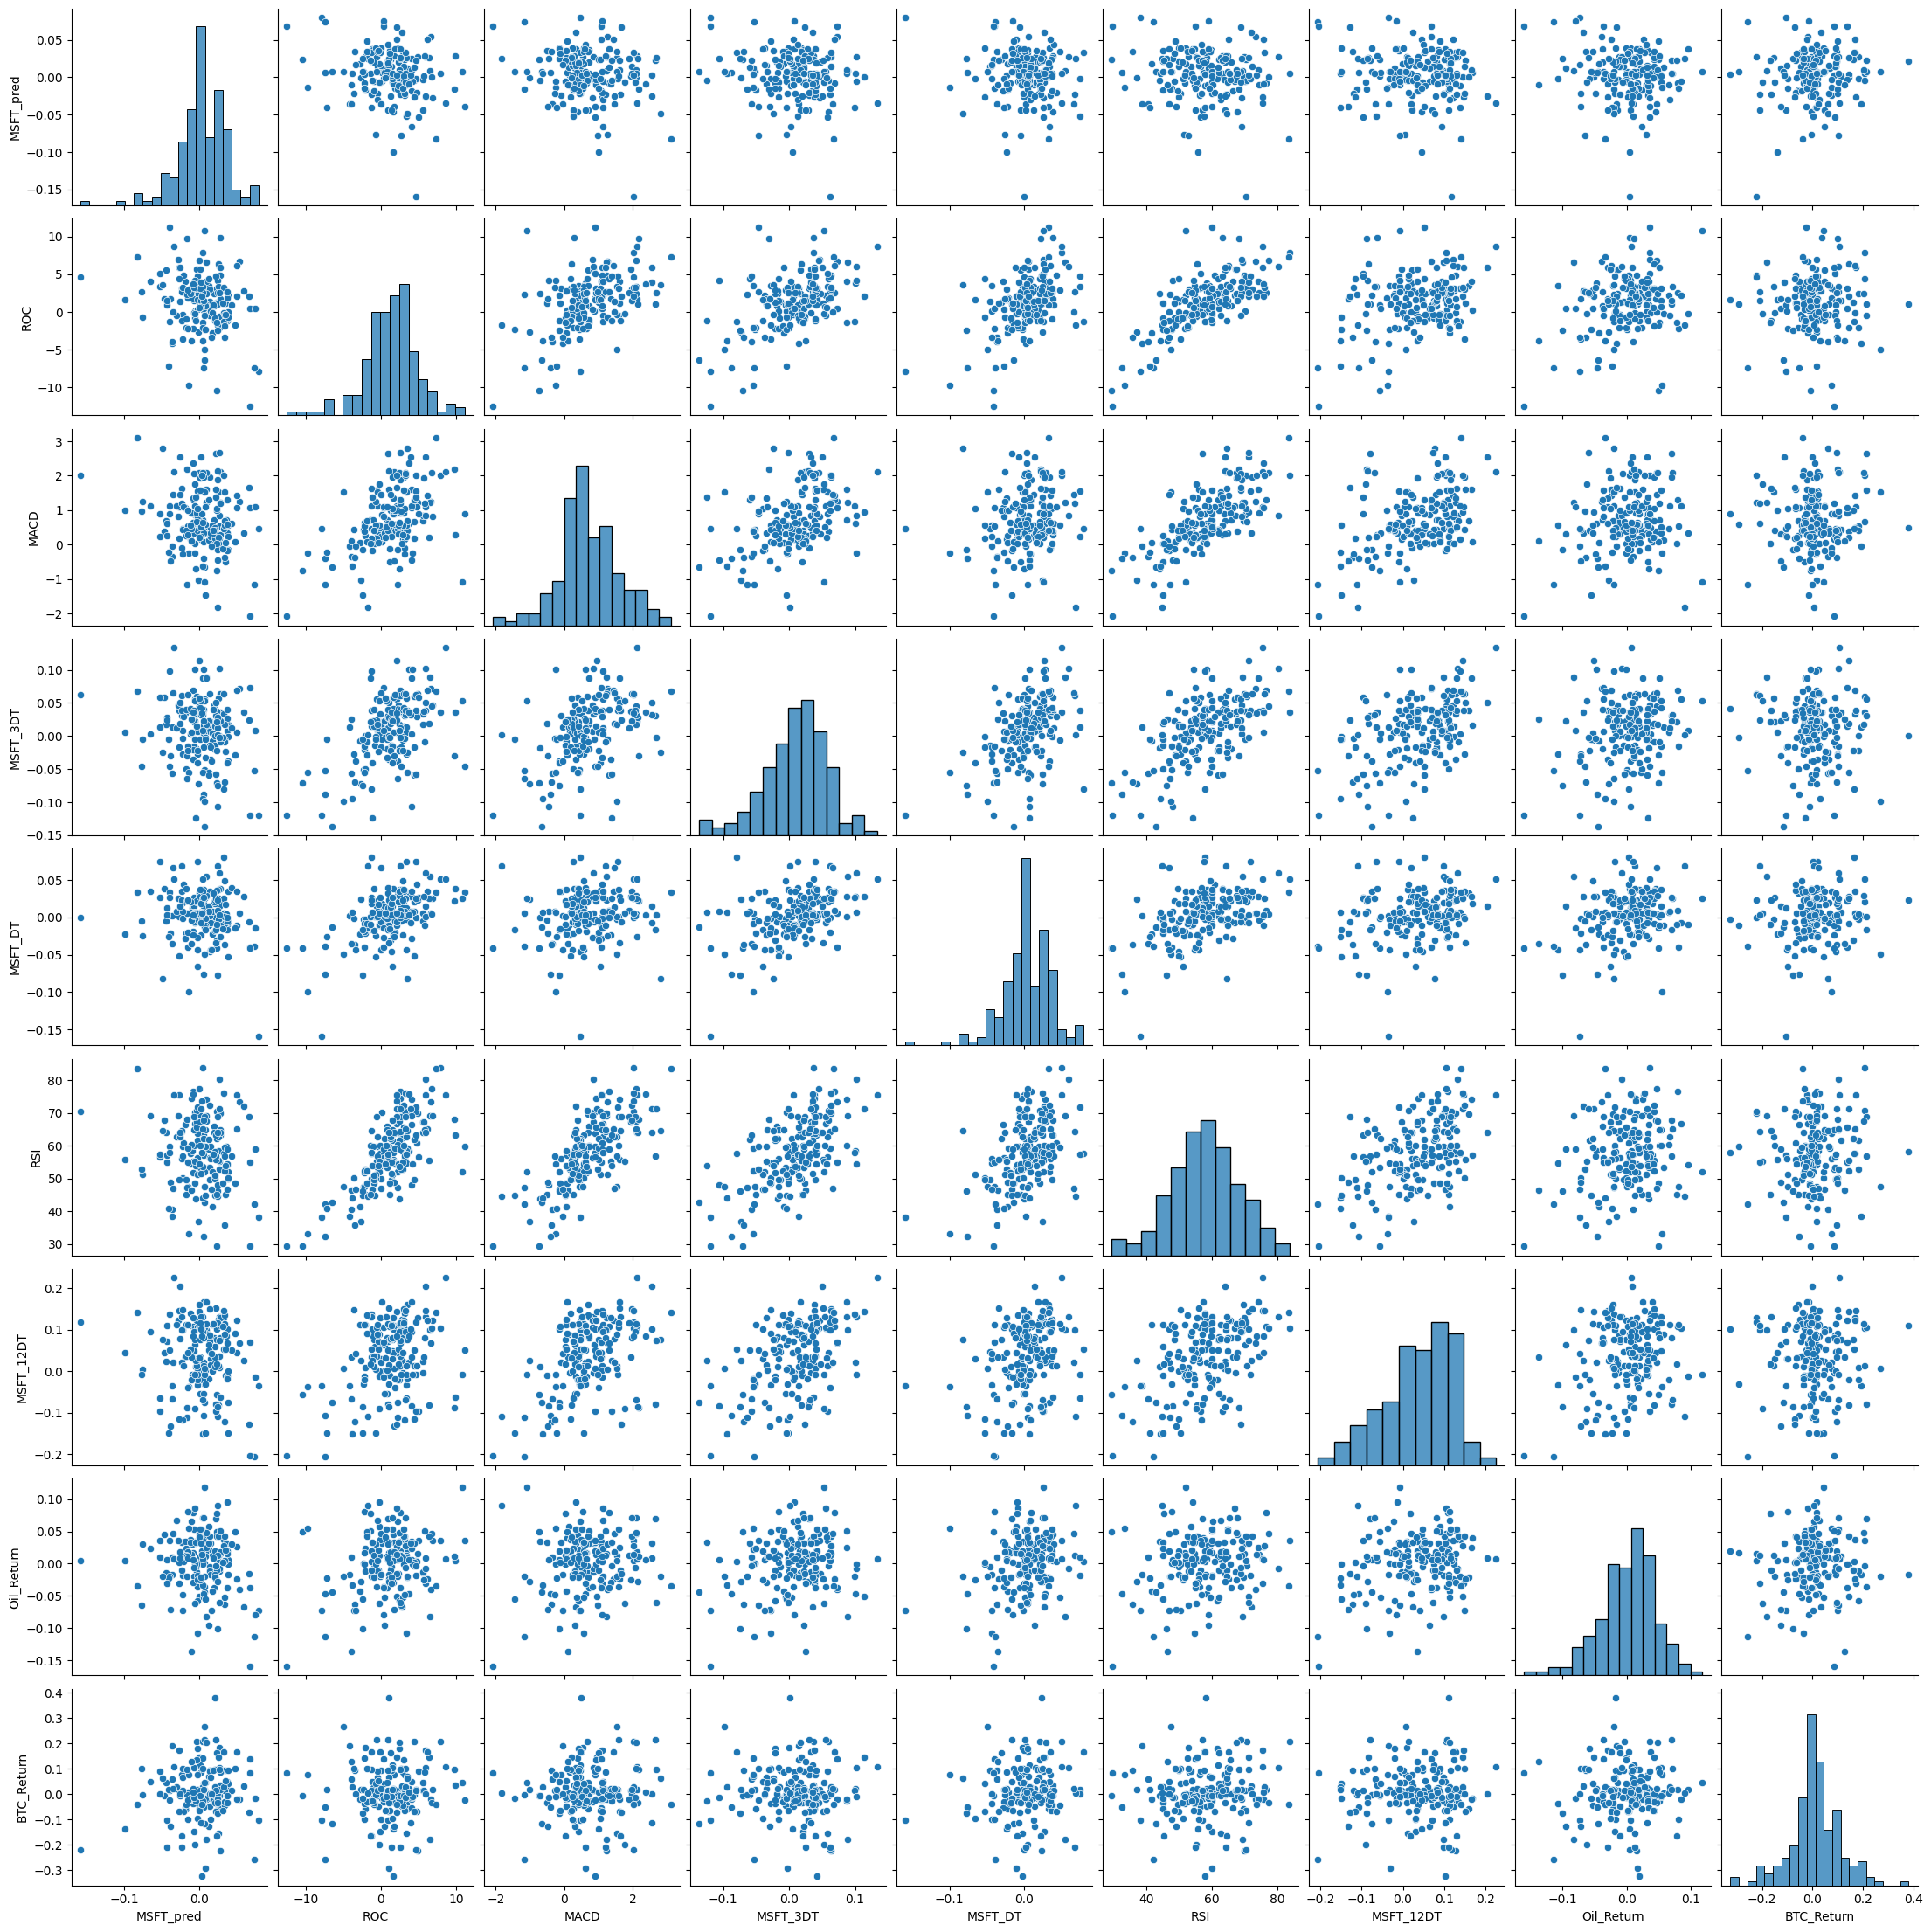

In [30]:
plot_cols = ["MSFT_pred"] + top_features
sns.pairplot(df[plot_cols])
plt.show()

## Observations

Some early observations from this EDA:

- the dataset is relatively small, which may make complex models harder to train well
- lagged MSFT return features seem to have stronger correlation with the target than many macro features
- feature scales are quite different, so scaling is important for models like LASSO, Elastic Net, KNN, and SVR
- the target is noisy and centered near zero, which is typical for financial return prediction